# Fit4Job RAG Evaluation

Evaluating the **Resume Feedback** and **Career Advice** tools with the RAGAS framework.

This notebook runs an instrumented copy of the Fit4Job RAG pipeline over the
resumes in `data/cv/` and scores the results with RAGAS reference-free metrics.
Retrieval, prompts, `top_k` and the generation model are identical to
`app/services/rag_service.py`, so the scores describe the live system.

| Stage | Model | Why |
|---|---|---|
| Generation | Gemini (`settings.gemini_model`) | The system under test |
| RAGAS judge | Groq (free tier) | Needs ~140 calls; Gemini's free tier allows 20/day |
| Embeddings | Local SBERT | No API quota |

## Before running

1. **Kernel** - select one whose environment has both the project's
   `requirements.txt` and the packages in section 1. Cell 2 checks this and
   stops with a clear message if not.
2. **Keys** - `GEMINI_API_KEY` and `GROQ_API_KEY` in `.env`.

Generation costs 20 Gemini calls, exactly the free-tier daily allowance.
Successful samples are cached to `evaluation_results/generated_samples.json`,
so an interrupted run resumes rather than restarting.


## 1. Install evaluation dependencies

RAGAS, the Groq judge adapter and the local embedding adapter are only needed
for evaluation, so they are not in the application's `requirements.txt`.
Run this cell once per environment, then restart the kernel.


In [1]:
# Run once, then restart the kernel. Versions are pinned: this notebook targets
# the RAGAS 0.2 metric API, and an unpinned "ragas" resolves to 0.4.x, which
# needs langchain 1.x and fails on import.
%pip install -q "ragas==0.2.15" "langchain>=0.3,<0.4" "langchain-core>=0.3,<0.4" "langchain-community>=0.3,<0.4" "langchain-openai>=0.2,<0.4" "langchain-groq>=0.2,<0.4" "langchain-huggingface>=0.1,<0.3" "google-generativeai==0.8.5" datasets nest_asyncio openpyxl XlsxWriter matplotlib


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: D:\1. UNI\Final Reserch Project\fit4job\venv\Scripts\python.exe -m pip install --upgrade pip


## 2. Project imports and configuration

The notebook lives in `notebooks/`, so this cell walks up to the project root
and changes into it, making `app.*` imports and the relative data paths resolve
exactly as they do when the server runs. It also verifies the kernel has every
required package before importing anything.

Loading `rag_service` builds the knowledge base index, so the first run takes a
few seconds.


In [2]:
import os
import sys
import json
import time
import random
import importlib
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")


def find_project_root(start: Path) -> Path:
    """The project root is the folder containing both app/ and run.py."""
    for candidate in [start, *start.parents]:
        if (candidate / "app").is_dir() and (candidate / "run.py").is_file():
            return candidate
    raise RuntimeError(
        f"Fit4Job project root not found from {start}. Run this notebook from "
        "inside the project; it needs the local repository."
    )


PROJECT_ROOT = find_project_root(Path.cwd().resolve())

# app.config reads .env and rag_service resolves data/ relatively, so the
# working directory must be the project root, not notebooks/.
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

# The kernel needs both requirements.txt and the evaluation packages.
REQUIRED = {
    "sentence_transformers": "sentence-transformers", "joblib": "joblib",
    "email_validator": "'pydantic[email]'", "pdfplumber": "pdfplumber",
    "docx": "python-docx", "google.generativeai": "google-generativeai",
    "ragas": "ragas==0.2.15", "langchain_groq": "langchain-groq",
    "langchain_huggingface": "langchain-huggingface", "datasets": "datasets",
    "xlsxwriter": "XlsxWriter", "openpyxl": "openpyxl", "matplotlib": "matplotlib",
}
missing = []
for module, package in REQUIRED.items():
    try:
        importlib.import_module(module)
    except Exception:
        missing.append(package)

if missing:
    raise RuntimeError(
        f"Wrong kernel: {sys.executable}\n"
        f"Missing: {', '.join(missing)}\n\n"
        "Select the kernel whose environment has the project's requirements.txt "
        "installed, or install the missing packages into this one."
    )

from app.config import get_settings                      # noqa: E402
from app.services.rag_service import knowledge_base      # noqa: E402
from app.services import rag_service                     # noqa: E402
from app.services import resume_parser                   # noqa: E402

settings = get_settings()

CV_DIR = PROJECT_ROOT / "data" / "cv"
KB_DIR = PROJECT_ROOT / "data" / "knowledge_base"
RESULTS_DIR = PROJECT_ROOT / "evaluation_results"
RESULTS_DIR.mkdir(exist_ok=True)

# 10 resumes = 20 samples. The judge costs ~13k tokens per sample and each
# Groq key is capped at 200k tokens/day, so the two tools are scored under
# separate keys (~130k each). With one key only, lower this to 5.
N_RESUMES = 10        # resumes to evaluate
TOP_K = 4             # retrieved chunks per query, same as the app

for path in (CV_DIR, KB_DIR):
    if not path.is_dir():
        raise FileNotFoundError(f"{path} does not exist.")

# Without SBERT the app falls back to a hashing encoder, which would make the
# scores describe a different retriever than the one in production.
USING_SBERT = getattr(rag_service.embedding_service, "model", None) is not None
if not USING_SBERT:
    print("WARNING: SBERT unavailable, retrieval is using the hashing fallback. "
          "Scores would not describe the production system.\n")

# The Gemini free tier allows 20 requests/day per project, and generation needs
# 20. Any GEMINI_API_KEY* entries in .env are collected here; the pipeline
# rotates to the next key when one runs out of daily quota.
from dotenv import dotenv_values                          # noqa: E402

GEMINI_KEYS = [v.strip() for k, v in sorted(dotenv_values(PROJECT_ROOT / ".env").items())
               if k.startswith("GEMINI_API_KEY") and (v or "").strip()]
if not GEMINI_KEYS:
    raise RuntimeError("No GEMINI_API_KEY* found in .env.")

print(f"Project root      : {PROJECT_ROOT}")
print(f"Kernel            : {sys.executable}")
print(f"Retrieval encoder : {'SBERT (production)' if USING_SBERT else 'hashing fallback'}")
print(f"Knowledge base    : {len(knowledge_base.chunks)} chunks from "
      f"{len(knowledge_base.documents())} documents")
print(f"Generation model  : {settings.gemini_model}")
print(f"Gemini keys       : {len(GEMINI_KEYS)} (~{len(GEMINI_KEYS) * 20} calls/day)")


Project root      : D:\1. UNI\Final Reserch Project\fit4job
Kernel            : D:\1. UNI\Final Reserch Project\fit4job\venv\Scripts\python.exe
Retrieval encoder : SBERT (production)
Knowledge base    : 1921 chunks from 13 documents
Generation model  : gemini-3.6-flash
Gemini keys       : 4 (~80 calls/day)


## 3. Load the resumes

Every PDF, DOCX or TXT file in `data/cv/` is read with the same parser the web
application uses, so the evaluation sees exactly the text the live system sees.

This is a real evaluation: the notebook reads whatever CVs you have placed in
that folder and does not generate or substitute any sample data. If the folder
is empty the next cell stops with a clear error.

In [3]:
def load_resumes(limit: int = N_RESUMES) -> list[dict]:
    """Read resume files with the application's own parser so the evaluation
    sees exactly the text the live system would see."""
    if not CV_DIR.is_dir():
        raise FileNotFoundError(
            f"{CV_DIR} does not exist. Create it and add your resume files "
            "(PDF, DOCX or TXT) before running the evaluation."
        )

    files = sorted([p for p in CV_DIR.iterdir()
                    if p.suffix.lower() in {".pdf", ".docx", ".txt"} and p.is_file()])
    if not files:
        raise FileNotFoundError(
            f"No PDF, DOCX or TXT files found in {CV_DIR}. "
            "Add your resumes there before running the evaluation."
        )

    resumes = []
    for path in files[:limit]:
        content = path.read_bytes()
        text = resume_parser.extract_text(path.name, content)
        if not text.strip():
            print(f"  skipped {path.name}: no extractable text "
                  "(scanned image PDF, or an unsupported encoding)")
            continue
        parsed = resume_parser.parse_resume(text)
        resumes.append({
            "resume_id": f"CV{len(resumes) + 1:02d}",
            "filename": path.name,
            "text": text,
            "word_count": parsed["word_count"],
            "detected_skills": parsed["detected_skills"],
        })

    if not resumes:
        raise RuntimeError(
            "No readable text could be extracted from any file in data/cv/. "
            "If these are scanned PDFs they need OCR before they can be evaluated."
        )
    return resumes


resumes = load_resumes()

print(f"Loaded {len(resumes)} resumes from {CV_DIR}\n")
summary = pd.DataFrame([{
    "Resume ID": r["resume_id"],
    "File": r["filename"],
    "Words": r["word_count"],
    "Skills detected": len(r["detected_skills"]),
    "Top skills": ", ".join(r["detected_skills"][:6]),
} for r in resumes])
display(summary)

if len(resumes) < N_RESUMES:
    print(f"\nNote: {len(resumes)} readable resume(s) available out of the "
          f"{N_RESUMES} requested. The evaluation will run on these.")

Loaded 5 resumes from D:\1. UNI\Final Reserch Project\fit4job\data\cv



,Resume ID,File,Words,Skills detected,Top skills
0,CV01,AI & ML Engineer 1.pdf,615,36,"AWS, C, CI/CD, CRM, Claude API, Cloud"
1,CV02,Data Analyst 1.pdf,979,30,"Backup, Business Intelligence, Communication, ..."
2,CV03,Mobile App Developer 1.pdf,429,21,"AWS, CSS, Communication, Computer Science, Dee..."
3,CV04,NOC Engineer 1.pdf,467,27,"Arduino, CSS, Cisco, Communication, Cybersecur..."
4,CV05,Senior Software Engineer 1.pdf,815,67,"AWS, Agile, Amazon Lambda, Azure, Azure Functi..."



Note: 5 readable resume(s) available out of the 10 requested. The evaluation will run on these.


## 4. The instrumented RAG pipeline

`app/services/rag_service.py` returns only the final answer, but RAGAS needs
the retrieved context chunks as well in order to measure grounding.

The functions below reproduce the production pipeline exactly - same retrieval
call, same `top_k`, same prompt text, same Gemini model, same output cleaning -
but they also return the retrieved chunks and timing. Nothing about the
generation behaviour changes, so the scores describe the real system.

### 4.1 Gemini call handling

Retry, quota classification and key rotation. Only error handling and
credentials are added here; the prompts, model and parameters stay exactly
production's.


In [4]:
import logging


def retrieve_contexts(query: str, top_k: int = TOP_K) -> list[dict]:
    """Same retrieval as rag_service._context_block, returning raw chunks."""
    return knowledge_base.retrieve(query, top_k=top_k)


def build_context_block(chunks: list[dict]) -> str:
    return "\n\n".join(f"[{c['source']}]\n{c['text']}" for c in chunks)


# _call_gemini returns None for every failure, so capture its log record to
# tell a retryable error from an exhausted daily quota.
class _FailureCapture(logging.Handler):
    def __init__(self):
        super().__init__(level=logging.WARNING)
        self.last_message = ""

    def emit(self, record):
        self.last_message = record.getMessage()


_capture = _FailureCapture()
logging.getLogger(rag_service.__name__).addHandler(_capture)

DAILY_QUOTA_MARKERS = ("perdayperproject", "requests per day",
                       "generate_content_free_tier_requests")


class DailyQuotaExhausted(RuntimeError):
    """The Gemini per-day free-tier allowance is gone."""


MAX_RETRIES = 4
BACKOFF_BASE = 4.0


_key_index = 0
settings.gemini_api_key = GEMINI_KEYS[_key_index]


def _next_gemini_key() -> bool:
    """Switch to the next unused key. Returns False when none are left.

    settings is the lru_cached instance rag_service._call_gemini reads on every
    call, so assigning here redirects the very next request. Only the
    credential changes; prompt, model and parameters stay production's."""
    global _key_index
    if _key_index + 1 >= len(GEMINI_KEYS):
        return False
    _key_index += 1
    settings.gemini_api_key = GEMINI_KEYS[_key_index]
    print(f"      daily quota gone; switching to Gemini key "
          f"{_key_index + 1}/{len(GEMINI_KEYS)}")
    return True


def call_gemini_with_retry(prompt: str, label: str = "") -> str | None:
    """Call the app's own Gemini function, retrying only when it can help and
    rotating keys when one key's daily quota is exhausted."""
    while True:
        for attempt in range(1, MAX_RETRIES + 1):
            _capture.last_message = ""
            raw = rag_service._call_gemini(prompt)
            if raw is not None:
                return raw

            if any(m in _capture.last_message.lower() for m in DAILY_QUOTA_MARKERS):
                break                      # key exhausted; rotate below

            if attempt == MAX_RETRIES:
                return None
            wait = BACKOFF_BASE * (2 ** (attempt - 1)) + random.uniform(0, 1.5)
            print(f"      {label} failed, attempt {attempt}/{MAX_RETRIES}; "
                  f"retrying in {wait:.1f}s")
            time.sleep(wait)
        else:
            return None

        if not _next_gemini_key():
            raise DailyQuotaExhausted(
                f"All {len(GEMINI_KEYS)} Gemini key(s) have exhausted their daily "
                "free-tier quota. Limits reset every 24h at midnight US Pacific; "
                "add another GEMINI_API_KEY_N to .env to continue sooner."
            )


### 4.2 The two tools

Each function mirrors its counterpart in `rag_service.py` and additionally
returns the retrieved chunks and timing that RAGAS needs.


In [5]:
PLAIN_TEXT_RULE = (
    "Respond in plain text only, no markdown symbols such as asterisks or hashes. "
    "Structure the answer with short section titles ending in a colon, followed by "
    "short numbered points or dashes. Keep every sentence short and simple. "
    "Never write long paragraphs. "
)

OFFLINE_ADVICE = (
    "Recommended approach: compare your detected skills against the roadmaps in "
    "the Learning section, pick the domain with the highest existing coverage, "
    "and close the earliest incomplete stage first. Re-run job matching monthly "
    "to track how your match scores improve."
)


def _offline_feedback(resume_text: str) -> str:
    wc = len(resume_text.split())
    fit = "appropriate" if 250 <= wc <= 700 else "consider adjusting toward 300-600 words"
    return (
        "Strengths: resume submitted with detectable structure.\n"
        f"Length check: {wc} words ({fit}).\n"
        "Suggestions:\n"
        "1. Start each bullet with a strong action verb and a measurable outcome.\n"
        "2. Mirror genuine skills from the target job description near the top.\n"
        "3. Quantify impact (latency, users, cost, coverage) wherever honest numbers exist.\n"
        "4. Add links to code or live projects.\n"
        "5. Remove generic objectives and unsupported soft-skill claims."
    )


def run_resume_feedback(resume_text: str) -> dict:
    """Mirrors rag_service.generate_resume_feedback with job_id=None."""
    retrieval_query = "resume writing improvement technology roles"
    chunks = retrieve_contexts(retrieval_query)
    prompt = (
        "You are a professional technical resume reviewer. " + PLAIN_TEXT_RULE +
        " Using the reference context, give structured feedback on the resume below: "
        "strengths, weaknesses, missing keywords for the target role, and five "
        "concrete rewrite suggestions.\n\n"
        "No specific target role.\n\n"
        f"RESUME:\n{resume_text[:6000]}\n\n"
        f"REFERENCE CONTEXT:\n{build_context_block(chunks)}"
    )

    started = time.time()
    raw = call_gemini_with_retry(prompt, "Resume Feedback")
    elapsed = time.time() - started

    return {
        "tool": "Resume Feedback",
        "retrieval_query": retrieval_query,
        "user_input": ("Review this resume and give structured feedback: strengths, "
                       "weaknesses, missing keywords for technology roles, and five "
                       "concrete rewrite suggestions."),
        "contexts": [c["text"] for c in chunks],
        "context_sources": [c["source"] for c in chunks],
        "answer": rag_service.clean_output(raw if raw is not None
                                           else _offline_feedback(resume_text)),
        "mode": "gemini" if raw is not None else "offline",
        "latency_s": round(elapsed, 2),
    }


def run_career_advice(resume_text: str) -> dict:
    """Mirrors rag_service.career_recommendation."""
    # Mirrors rag_service.career_recommendation: skill-aware query, restricted
    # to career sources, top_k=6. A generic query retrieved career philosophy
    # and book chunks instead of the track-matching paragraphs.
    retrieval_query = rag_service._career_query(resume_text)
    chunks = knowledge_base.retrieve(retrieval_query,
                                     top_k=rag_service.CAREER_TOP_K,
                                     sources=rag_service.CAREER_SOURCES)
    prompt = (
        "You are a career advisor for IT professionals in Sri Lanka. " + PLAIN_TEXT_RULE +
        " Based on the resume and reference context, recommend the two best-fit "
        "career tracks, the next three skills to learn, and a 6-month plan.\n\n"
        f"RESUME:\n{resume_text[:6000]}\n\n"
        f"REFERENCE CONTEXT:\n{build_context_block(chunks)}"
    )

    started = time.time()
    raw = call_gemini_with_retry(prompt, "Career Advice")
    elapsed = time.time() - started

    return {
        "tool": "Career Advice",
        "retrieval_query": retrieval_query,
        "user_input": ("Based on this resume, recommend the two best-fit career "
                       "tracks, the next three skills to learn, and a six month plan."),
        "contexts": [c["text"] for c in chunks],
        "context_sources": [c["source"] for c in chunks],
        "answer": rag_service.clean_output(raw if raw is not None else OFFLINE_ADVICE),
        "mode": "gemini" if raw is not None else "offline",
        "latency_s": round(elapsed, 2),
    }


# Retrieval is local, so this sanity check costs no API quota.
probe = retrieve_contexts("resume writing improvement technology roles")
print(f"Retrieved {len(probe)} chunks:")
for c in probe:
    print(f"  [{c['source']}] {c['text'][:80]}...")


Retrieved 4 chunks:
  [resume_writing_reference] Resume writing for technology roles is scanned by a recruiter in six to eight se...
  [resume_writing_reference] The most diagnosable weakness in fresh graduate resumes across all technology ro...
  [resume_writing_reference] Resume length should be one page for candidates with fewer than ten years of exp...
  [resume_writing_reference] The single highest-impact resume improvement available to most mid-level and sen...


## 5. Run the pipeline over all resumes

Each resume passes through both tools, producing 2 x N samples. Every sample
records the request, the retrieved contexts and the generated answer - the
three inputs RAGAS needs for reference-free scoring.

This is the only stage that spends Gemini quota: 2 calls per resume, 20 in
total, which is exactly the free-tier daily allowance. Samples are cached as
they succeed, so re-running after a quota reset continues where it stopped.

Samples that fall back to the offline template are excluded from scoring - they
would measure the fallback rather than the real system.


In [6]:
PAUSE_SECONDS = 2.0
CACHE_PATH = RESULTS_DIR / "generated_samples.json"

# Samples are cached so an interrupted run resumes instead of restarting.
cached = json.loads(CACHE_PATH.read_text(encoding="utf-8")) if CACHE_PATH.exists() else []

# The cache may hold samples from a larger previous run. Keep only the
# resumes selected now, so N_RESUMES actually controls what gets scored.
wanted_files = {r["filename"] for r in resumes}
samples = [s for s in cached if s["filename"] in wanted_files]
if len(cached) != len(samples):
    print(f"Cache holds {len(cached)} sample(s); using the {len(samples)} "
          f"for the {len(resumes)} selected resume(s).")
done = {(s["filename"], s["tool"]) for s in samples}
if samples:
    print(f"Resuming: {len(samples)} sample(s) loaded from {CACHE_PATH.name}\n")

quota_exhausted = False

for i, resume in enumerate(resumes, 1):
    if quota_exhausted:
        break
    print(f"[{i}/{len(resumes)}] {resume['resume_id']} - {resume['filename']}")

    for tool_name, runner in [("Resume Feedback", run_resume_feedback),
                              ("Career Advice", run_career_advice)]:
        if (resume["filename"], tool_name) in done:
            print(f"    {tool_name:<16}: cached, skipping")
            continue

        try:
            sample = runner(resume["text"])
        except DailyQuotaExhausted as exc:
            print(f"\nSTOPPED: {exc}\n")
            quota_exhausted = True
            break
        except Exception as exc:
            print(f"    {tool_name:<16}: FAILED - {type(exc).__name__}: {exc}")
            continue

        sample.update(resume_id=resume["resume_id"], filename=resume["filename"])
        samples.append(sample)
        done.add((resume["filename"], tool_name))
        cached = [c for c in cached
                  if (c["filename"], c["tool"]) != (sample["filename"], tool_name)]
        cached.append(sample)
        CACHE_PATH.write_text(json.dumps(cached, indent=1), encoding="utf-8")

        print(f"    {tool_name:<16}: {sample['mode']}, {sample['latency_s']}s, "
              f"{len(sample['answer'].split())} words")
        time.sleep(PAUSE_SECONDS)

# Re-label cached samples so IDs match the current resume selection.
id_by_file = {r["filename"]: r["resume_id"] for r in resumes}
for smp in samples:
    smp["resume_id"] = id_by_file.get(smp["filename"], smp["resume_id"])
samples.sort(key=lambda x: (x["resume_id"], x["tool"]))

expected = len(resumes) * 2
print(f"\n{len(samples)}/{expected} samples ready (cached in {CACHE_PATH.name})")

if not samples:
    raise RuntimeError("No samples generated. Check GEMINI_API_KEY and quota.")

# Offline samples are the fallback template, not the real system. Scoring them
# would measure the template, so they are excluded from the evaluation.
offline = [s for s in samples if s["mode"] == "offline"]
if offline:
    print(f"\nExcluding {len(offline)} offline-fallback sample(s) - these did not "
          "reach Gemini and would not describe the real system.")
    samples = [s for s in samples if s["mode"] == "gemini"]

if not samples:
    raise RuntimeError(
        "Every sample used the offline fallback, so there is nothing meaningful "
        "to score. Wait for the Gemini daily quota to reset, then re-run."
    )

if quota_exhausted or len(samples) < expected:
    print(f"\nIncomplete: {len(samples)}/{expected} samples. Re-run this cell after "
          "the Gemini quota resets to generate the rest; cached samples are kept.")


Cache holds 10 sample(s); using the 5 for the 5 selected resume(s).
Resuming: 5 sample(s) loaded from generated_samples.json

[1/5] CV01 - AI & ML Engineer 1.pdf
    Resume Feedback : cached, skipping


    Career Advice   : gemini, 39.17s, 114 words


[2/5] CV02 - Data Analyst 1.pdf
    Resume Feedback : cached, skipping


    Career Advice   : gemini, 10.65s, 112 words


[3/5] CV03 - Mobile App Developer 1.pdf
    Resume Feedback : cached, skipping


...

[4/5] CV04 - NOC Engineer 1.pdf
    Resume Feedback : cached, skipping


    Career Advice   : gemini, 12.73s, 182 words


[5/5] CV05 - Senior Software Engineer 1.pdf
    Resume Feedback : cached, skipping


    Career Advice   : gemini, 13.13s, 152 words



10/10 samples ready (cached in generated_samples.json)


### 5.1 Inspect one answer

A quick eyeball check that the pipeline produced sensible output.


In [7]:
# Inspect one generated answer to confirm the pipeline is producing sensible output.
if not samples:
    print("No samples were generated, nothing to show.")
else:
    example = samples[0]
    print(f"Tool      : {example['tool']}")
    print(f"Resume    : {example['resume_id']} ({example['filename']})")
    print(f"Mode      : {example['mode']}")
    print(f"Contexts  : {', '.join(example['context_sources'])}")
    print("\n--- ANSWER ---\n")
    print(example["answer"][:1800])


Tool      : Career Advice
Resume    : CV01 (AI & ML Engineer 1.pdf)
Mode      : gemini
Contexts  : career_development_reference, career_development_reference, career_development_reference, career_development_reference, career_development_reference, career_development_reference

--- ANSWER ---

Recommended Career Tracks:

1. Cloud Solutions Architect. Your experience in Docker, Jenkins, and cloud infrastructure aligns directly with this role.
2. Cloud Platform Engineer. Your background in configuring cloud compute clusters and deployment pipelines fits this track well.

Next Three Skills to Learn:

1. Terraform for infrastructure as code.
2. Kubernetes for container orchestration at scale.
3. Formal cost modelling and multi-cloud comparison across AWS, Azure, and Google Cloud.

Six Month Plan:
- Month 1 and Month 2: Master Linux and Docker.
- Month 3 and Month 4: Learn Terraform and platform comparison.
- Month 5 and Month 6: Study Kubernetes and high availability design.
- Final Delive

## 6. Configure RAGAS

Neither tool has a single correct answer, so only reference-free metrics are
used. Ground-truth metrics such as context recall and answer correctness do not
apply here and are deliberately excluded.

| Metric | Question it answers |
|---|---|
| **Faithfulness** | Are the answer's claims supported by the retrieved context, or invented? |
| **Answer Relevancy** | Does the answer address what was asked, without padding? |
| **Context Utilisation** | Were the useful chunks ranked highly, judged against the answer? |

All three score 0 to 1, higher is better.


In [8]:
from langchain_groq import ChatGroq
from langchain_huggingface import HuggingFaceEmbeddings
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper

# Generation = Gemini (system under test). Judging = Groq, which has the
# throughput Gemini's free tier lacks. Embeddings run locally, no quota.

from dotenv import dotenv_values

# Each Groq key has its own daily token budget.
_env = dotenv_values(PROJECT_ROOT / ".env")
GROQ_KEYS = [v.strip() for k, v in sorted(_env.items())
             if k.startswith("GROQ_API_KEY") and (v or "").strip()]
if os.getenv("GROQ_API_KEY", "").strip() and os.environ["GROQ_API_KEY"] not in GROQ_KEYS:
    GROQ_KEYS.insert(0, os.environ["GROQ_API_KEY"].strip())

if not GROQ_KEYS:
    raise RuntimeError(
        "No GROQ_API_KEY found. Get a free key at https://console.groq.com "
        f"and add 'GROQ_API_KEY=...' to {PROJECT_ROOT / '.env'}."
    )
os.environ["GROQ_API_KEY"] = GROQ_KEYS[0]

# Probed with a tiny call so an unavailable model fails here with a clear
# message, rather than silently yielding an all-NaN score table.
JUDGE_CANDIDATES = ["openai/gpt-oss-20b", "qwen/qwen3.8-27b", "openai/gpt-oss-120b"]

JUDGE_MODEL, probe_errors = None, {}
for candidate in JUDGE_CANDIDATES:
    try:
        ChatGroq(model=candidate, temperature=0.0, max_tokens=16).invoke("ping")
        JUDGE_MODEL = candidate
        break
    except Exception as exc:
        probe_errors[candidate] = f"{type(exc).__name__}: {str(exc)[:120]}"

if JUDGE_MODEL is None:
    raise RuntimeError("No Groq judge model reachable:\n" +
                       "\n".join(f"  {m}: {e}" for m, e in probe_errors.items()))

# Reasoning models spend output budget before emitting JSON; too small a
# max_tokens truncates it and RAGAS records a silent NaN.
JUDGE_KWARGS = dict(temperature=0.0, max_retries=5, timeout=180, max_tokens=4096)
if JUDGE_MODEL.startswith("openai/gpt-oss"):
    JUDGE_KWARGS["reasoning_effort"] = "low"

def make_judge(key_index: int) -> LangchainLLMWrapper:
    """Judge bound to one specific Groq key, so its token budget is isolated."""
    key = GROQ_KEYS[key_index % len(GROQ_KEYS)]
    return LangchainLLMWrapper(ChatGroq(model=JUDGE_MODEL, api_key=key, **JUDGE_KWARGS))


judge_llm = make_judge(0)

# Reuse the app's own SBERT artifacts when present so the embedding space
# matches the retriever; otherwise the same base model it falls back to.
_sbert = PROJECT_ROOT / settings.sbert_model_path
EMBED_MODEL = str(_sbert) if _sbert.is_dir() else "sentence-transformers/all-MiniLM-L6-v2"
judge_embeddings = LangchainEmbeddingsWrapper(HuggingFaceEmbeddings(
    model_name=EMBED_MODEL, encode_kwargs={"normalize_embeddings": True},
))

print(f"Generation model  : {settings.gemini_model} (Gemini, system under test)")
print(f"RAGAS judge LLM   : {JUDGE_MODEL} (Groq, {len(GROQ_KEYS)} key(s))")
print(f"RAGAS embeddings  : {EMBED_MODEL} (local, no quota)")


Generation model  : gemini-3.6-flash (Gemini, system under test)
RAGAS judge LLM   : openai/gpt-oss-20b (Groq, 5 key(s))
RAGAS embeddings  : sentence-transformers/all-MiniLM-L6-v2 (local, no quota)


### 6.1 Metric set

Metric column names are read from the metric objects rather than hard-coded,
so a RAGAS version change cannot silently yield an empty score table.


In [9]:
# Import the metric set, tolerating naming differences across RAGAS versions.
import ragas
from ragas import evaluate

RAGAS_VERSION = getattr(ragas, "__version__", "unknown")

try:
    # RAGAS 0.2+ class-based API
    from ragas.metrics import Faithfulness, ResponseRelevancy
    from ragas.metrics import LLMContextPrecisionWithoutReference
    # Grounding metrics need the resume in context; retrieval metrics must
    # not see it, or it inflates the ranking score.
    def build_metrics(llm):
        """Metrics bound to a given judge, so each tool can use its own key."""
        return ([Faithfulness(llm=llm),
                 ResponseRelevancy(llm=llm, embeddings=judge_embeddings)],
                [LLMContextPrecisionWithoutReference(llm=llm)])

    METRICS_GROUNDING, METRICS_RETRIEVAL = build_metrics(judge_llm)
    METRICS = METRICS_GROUNDING + METRICS_RETRIEVAL
    RAGAS_API = "0.2"
except (ImportError, AttributeError):
    try:
        # RAGAS 0.1 function-style API
        from ragas.metrics import faithfulness, answer_relevancy, context_utilization
        def build_metrics(llm):
            return ([faithfulness, answer_relevancy], [context_utilization])

        METRICS_GROUNDING, METRICS_RETRIEVAL = build_metrics(judge_llm)
        METRICS = METRICS_GROUNDING + METRICS_RETRIEVAL
        RAGAS_API = "0.1"
    except (ImportError, AttributeError) as exc:
        raise ImportError(
            f"Installed ragas {RAGAS_VERSION} exposes neither the 0.2 class-based "
            f"metrics nor the 0.1 function-style metrics ({exc}).\n"
            "This notebook targets the 0.2 API. Reinstall with:\n\n"
            '    pip install "ragas==0.2.15" "langchain>=0.3,<0.4" '
            '"langchain-core>=0.3,<0.4" "langchain-community>=0.3,<0.4" '
            '"langchain-openai>=0.2,<0.4" "langchain-google-genai==2.0.9"'
        ) from exc

# Derive the score column names from the metric objects themselves rather than
# hard-coding them, so a version bump that renames a metric cannot silently
# produce an empty score table.
METRIC_COLUMNS = [getattr(m, "name", str(m)) for m in METRICS]

# Friendly names used throughout the report and the Excel workbook.
METRIC_LABELS = {
    "faithfulness": "Faithfulness",
    "answer_relevancy": "Answer Relevancy",
    "context_utilization": "Context Utilisation",
    "llm_context_precision_without_reference": "Context Utilisation",
}
# Any metric name not in the table above falls back to a title-cased version.
for col in METRIC_COLUMNS:
    METRIC_LABELS.setdefault(col, col.replace("_", " ").title())

print(f"RAGAS version     : {RAGAS_VERSION} (using the {RAGAS_API} API)")
print(f"Metric columns    : {METRIC_COLUMNS}")
print(f"Reported as       : {[METRIC_LABELS[c] for c in METRIC_COLUMNS]}")


RAGAS version     : 0.2.15 (using the 0.2 API)
Metric columns    : ['faithfulness', 'answer_relevancy', 'llm_context_precision_without_reference']
Reported as       : ['Faithfulness', 'Answer Relevancy', 'Context Utilisation']


## 7. Evaluate

Each tool is scored separately so the two can be compared, then the results are
combined into a single system-level view. RAGAS makes several judge calls per
sample, so this step is the slowest part of the notebook.

### 7.1 Scoring helpers


In [10]:
RESUME_TEXT = {r["resume_id"]: r["text"] for r in resumes}


def build_dataset(rows: list[dict], include_resume: bool):
    """Build the evaluation dataset in the shape the installed RAGAS expects.

    include_resume prepends the same resume excerpt the generation prompt used.
    Grounding metrics need it (otherwise every resume-specific claim looks
    unsupported); retrieval metrics must not see it."""
    def contexts_for(r):
        ctx = list(r["contexts"])
        if include_resume:
            ctx = [RESUME_TEXT[r["resume_id"]][:6000]] + ctx
        return ctx

    if RAGAS_API == "0.2":
        from ragas import EvaluationDataset
        return EvaluationDataset.from_list([{
            "user_input": r["user_input"],
            "retrieved_contexts": contexts_for(r),
            "response": r["answer"],
        } for r in rows])

    from datasets import Dataset
    return Dataset.from_dict({
        "question": [r["user_input"] for r in rows],
        "contexts": [contexts_for(r) for r in rows],
        "answer": [r["answer"] for r in rows],
    })


# RAGAS defaults to 16 workers / 180s, which rate-limits then times out on a
# free tier. Fewer workers and a longer timeout instead.
from ragas.run_config import RunConfig

# Groq allows 8k tokens/minute per key. With the resume in the grounding
# context each call is ~2.5k tokens, so 2 workers is the safe ceiling.
RUN_CONFIG = RunConfig(timeout=900, max_workers=1, max_retries=6, max_wait=45)

EVAL_MAX_RETRIES = 3
EVAL_BACKOFF_BASE = 10.0


def evaluate_with_retry(dataset, metrics, label: str):
    """Run RAGAS evaluate() with exponential backoff on rate limits."""
    for attempt in range(1, EVAL_MAX_RETRIES + 1):
        try:
            return evaluate(
                dataset=dataset,
                metrics=metrics,
                llm=judge_llm,
                embeddings=judge_embeddings,
                run_config=RUN_CONFIG,
            )
        except Exception as exc:
            message = str(exc)
            rate_limited = "429" in message or "quota" in message.lower() \
                or "rate" in message.lower()
            if attempt == EVAL_MAX_RETRIES:
                print(f"  evaluate() failed for {label} after {attempt} attempts: "
                      f"{type(exc).__name__}: {exc}")
                return None
            wait = EVAL_BACKOFF_BASE * (2 ** (attempt - 1)) + random.uniform(0, 3)
            print(f"  evaluate() error for {label} "
                  f"({'rate limit' if rate_limited else type(exc).__name__}), "
                  f"attempt {attempt}/{EVAL_MAX_RETRIES}; retrying in {wait:.1f}s")
            time.sleep(wait)
    return None


def evaluate_tool(tool_name: str, key_index: int = 0) -> pd.DataFrame:
    """Score every sample for one tool and return a tidy per-resume table.

    Samples that RAGAS could not score keep a NaN in the metric columns; they
    are dropped from the means later rather than poisoning them."""
    rows = [s for s in samples if s["tool"] == tool_name]
    print(f"Evaluating {tool_name}: {len(rows)} samples ...")

    if not rows:
        print(f"  no samples for {tool_name}, skipping")
        return pd.DataFrame()

    # Each tool judged under its own Groq key to spread the token budget.
    tool_judge = make_judge(key_index)
    grounding, retrieval = build_metrics(tool_judge)
    print(f"  judge key {key_index + 1}/{len(GROQ_KEYS)}")

    # Two passes so each metric group sees the context it should.
    frames = []
    for metrics, with_resume, what in [
        (grounding, True, "grounding (resume + retrieved chunks)"),
        (retrieval, False, "retrieval (retrieved chunks only)"),
    ]:
        print(f"  {what} ...")
        res = evaluate_with_retry(build_dataset(rows, with_resume), metrics, tool_name)
        if res is None:
            continue
        part = res.to_pandas().reset_index(drop=True)
        wanted = [m.name for m in metrics if m.name in part.columns]
        frames.append(part[wanted])

    df = pd.concat(frames, axis=1) if frames else pd.DataFrame(index=range(len(rows)))
    print(f"  columns returned: {list(df.columns)}")

    # Reconcile the expected metric columns against what actually came back.
    present = [c for c in METRIC_COLUMNS if c in df.columns]
    missing = [c for c in METRIC_COLUMNS if c not in df.columns]
    if missing:
        print(f"  WARNING: expected metric column(s) not returned: {missing}")
        print(f"           actual columns: {list(df.columns)}")

    scores = df[present].copy() if present else pd.DataFrame(index=range(len(rows)))
    scores = scores.reset_index(drop=True)
    for col in missing:
        scores[col] = np.nan
    scores = scores[METRIC_COLUMNS]          # stable column order

    scores.insert(0, "Tool", tool_name)
    scores.insert(0, "File", [r["filename"] for r in rows])
    scores.insert(0, "Resume ID", [r["resume_id"] for r in rows])
    scores["Generator"] = [r["mode"] for r in rows]
    scores["Latency (s)"] = [r["latency_s"] for r in rows]
    scores["Answer words"] = [len(r["answer"].split()) for r in rows]

    scores = scores.rename(columns={c: METRIC_LABELS[c] for c in METRIC_COLUMNS})

    n_scored = int(scores[[METRIC_LABELS[c] for c in METRIC_COLUMNS]].notna().any(axis=1).sum())
    print(f"  done: {tool_name} ({n_scored}/{len(rows)} samples scored)")
    return scores


### 7.2 Run the evaluation

The slowest step: RAGAS makes several judge calls per sample.


In [11]:
# 20 samples cost ~260k judge tokens, above one key's 200k daily limit,
# so each tool is scored under a separate key.
feedback_scores = evaluate_tool("Resume Feedback", key_index=3)
advice_scores = evaluate_tool("Career Advice", key_index=2)

all_scores = pd.concat([f for f in (feedback_scores, advice_scores) if not f.empty],
                       ignore_index=True)

# METRIC_NAMES must match the columns actually present in all_scores before any
# groupby/mean runs downstream.
METRIC_NAMES = [METRIC_LABELS[c] for c in METRIC_COLUMNS]
METRIC_NAMES = list(dict.fromkeys(METRIC_NAMES))                 # de-duplicate, keep order
METRIC_NAMES = [m for m in METRIC_NAMES if m in all_scores.columns]

# A metric scored on a handful of samples is not a system measurement.
MIN_COVERAGE = 0.6

coverage = {m: all_scores[m].notna().mean() for m in METRIC_NAMES}
for m, frac in coverage.items():
    n = int(all_scores[m].notna().sum())
    flag = "   <- EXCLUDED, too few samples" if frac < MIN_COVERAGE else ""
    print(f"  coverage {m:<22} {frac:5.0%} ({n}/{len(all_scores)}){flag}")

weak = [m for m, frac in coverage.items() if frac < MIN_COVERAGE]
if weak:
    print(f"\nWARNING: {weak} scored on under {MIN_COVERAGE:.0%} of samples "
          "and are excluded. Re-run the evaluation to score them properly.")
    METRIC_NAMES = [m for m in METRIC_NAMES if m not in weak]

if not METRIC_NAMES:
    raise RuntimeError(
        "RAGAS returned no usable metric columns. Check the judge model is "
        "reachable and that the API key has quota."
    )

n_nan = int(all_scores[METRIC_NAMES].isna().sum().sum())
print(f"\nScored {len(all_scores)} samples on {len(METRIC_NAMES)} metrics "
      f"({METRIC_NAMES}).")
if n_nan:
    print(f"{n_nan} individual score(s) are NaN and will be excluded from the means.")


Evaluating Resume Feedback: 5 samples ...


  judge key 4/5
  grounding (resume + retrieved chunks) ...



Evaluating:   0%|          | 0/10 [00:00<?, ?it/s]


Evaluating:  10%|█         | 1/10 [00:32<04:53, 32.67s/it]


Evaluating:  20%|██        | 2/10 [01:09<04:42, 35.35s/it]

...


Evaluating:  80%|████████  | 4/5 [03:13<00:46, 46.11s/it]

Exception raised in Job[4]: RateLimitError(Error code: 429 - {'error': {'message': 'Rate limit reached for model `openai/gpt-oss-20b` in organization `org_01m1ddrhv7e8hv7t4ea1g4863j` service tier `on_demand` on tokens per day (TPD): Limit 200000, Used 199510, Requested 1535. Please try again in 7m31.439999999s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}})



Evaluating: 100%|██████████| 5/5 [04:24<00:00, 54.93s/it]


Evaluating: 100%|██████████| 5/5 [04:24<00:00, 52.83s/it]

  columns returned: ['faithfulness', 'answer_relevancy', 'llm_context_precision_without_reference']
  done: Career Advice (5/5 samples scored)
  coverage Faithfulness            100% (10/10)
  coverage Answer Relevancy        100% (10/10)
  coverage Context Utilisation      70% (7/10)

Scored 10 samples on 3 metrics (['Faithfulness', 'Answer Relevancy', 'Context Utilisation']).
3 individual score(s) are NaN and will be excluded from the means.


### 7.3 Per-resume scores


In [12]:
display(feedback_scores.round(3))
display(advice_scores.round(3))


,Resume ID,File,Tool,Faithfulness,Answer Relevancy,Context Utilisation,Generator,Latency (s),Answer words
0,CV01,AI & ML Engineer 1.pdf,Resume Feedback,0.583,0.721,0.833,gemini,13.59,166
1,CV02,Data Analyst 1.pdf,Resume Feedback,1.000,0.669,0.750,gemini,9.81,207
2,CV03,Mobile App Developer 1.pdf,Resume Feedback,0.952,0.642,0.750,gemini,14.34,214
3,CV04,NOC Engineer 1.pdf,Resume Feedback,1.000,0.693,NaN,gemini,10.95,218
4,CV05,Senior Software Engineer 1.pdf,Resume Feedback,0.867,0.664,NaN,gemini,15.06,358


,Resume ID,File,Tool,Faithfulness,Answer Relevancy,Context Utilisation,Generator,Latency (s),Answer words
0,CV01,AI & ML Engineer 1.pdf,Career Advice,0.909,0.578,0.667,gemini,39.17,114
1,CV02,Data Analyst 1.pdf,Career Advice,0.778,0.525,0.467,gemini,10.65,112
2,CV03,Mobile App Developer 1.pdf,Career Advice,0.091,0.534,0.167,gemini,17.18,149
3,CV04,NOC Engineer 1.pdf,Career Advice,1.000,0.564,0.887,gemini,12.73,182
4,CV05,Senior Software Engineer 1.pdf,Career Advice,0.727,0.673,NaN,gemini,13.13,152


## 8. Aggregate results

Three views are produced:

- **Per-tool summary** - mean, median, spread and worst case for each metric.
- **Overall system score** - the mean across both tools and all metrics, which
  is the single headline number for the RAG system.
- **Interpretation band** - a plain reading of what the score means.

In [13]:
def summarise(df: pd.DataFrame, label: str) -> pd.DataFrame:
    """Mean, median, spread and range per metric. NaN scores are dropped."""
    rows = []
    for metric in METRIC_NAMES:
        series = df[metric].dropna() if metric in df.columns else pd.Series(dtype=float)
        rows.append({
            "Scope": label,
            "Metric": metric,
            "Mean": series.mean(),
            "Median": series.median(),
            "Std dev": series.std(),
            "Minimum": series.min(),
            "Maximum": series.max(),
            "Samples": int(series.count()),
        })
    return pd.DataFrame(rows)


per_tool_summary = pd.concat([
    summarise(feedback_scores, "Resume Feedback"),
    summarise(advice_scores, "Career Advice"),
    summarise(all_scores, "Overall system"),
], ignore_index=True)

display(per_tool_summary.round(3))


,Scope,Metric,Mean,Median,Std dev,Minimum,Maximum,Samples
0,Resume Feedback,Faithfulness,0.880,0.952,0.175,0.583,1.000,5
1,Resume Feedback,Answer Relevancy,0.678,0.669,0.030,0.642,0.721,5
2,Resume Feedback,Context Utilisation,0.778,0.750,0.048,0.750,0.833,3
3,Career Advice,Faithfulness,0.701,0.778,0.358,0.091,1.000,5
4,Career Advice,Answer Relevancy,0.575,0.564,0.059,0.525,0.673,5
5,Career Advice,Context Utilisation,0.547,0.567,0.306,0.167,0.887,4
6,Overall system,Faithfulness,0.791,0.888,0.282,0.091,1.000,10
7,Overall system,Answer Relevancy,0.626,0.653,0.070,0.525,0.721,10
8,Overall system,Context Utilisation,0.646,0.750,0.251,0.167,0.887,7


### 8.1 Overall system score


In [14]:
def band(score: float) -> str:
    """Plain-language reading of a RAGAS score."""
    if pd.isna(score):
        return "Not scored"
    if score >= 0.85:
        return "Excellent"
    if score >= 0.70:
        return "Good"
    if score >= 0.55:
        return "Acceptable"
    if score >= 0.40:
        return "Weak"
    return "Poor"


# .mean() skips NaN by default, so failed samples are dropped rather than
# propagating into the aggregate.
overall_by_metric = all_scores[METRIC_NAMES].mean(skipna=True)
overall_score = float(overall_by_metric.mean(skipna=True))

print("=" * 62)
print("OVERALL RAG SYSTEM EVALUATION")
print("=" * 62)
print(f"Resumes evaluated : {all_scores['Resume ID'].nunique()}")
print(f"Tools evaluated   : Resume Feedback, Career Advice")
print(f"Samples scored    : {len(all_scores)}")
print(f"Judge model       : {JUDGE_MODEL}")
print("-" * 62)
for metric in METRIC_NAMES:
    value = float(overall_by_metric[metric])
    n = int(all_scores[metric].notna().sum())
    print(f"{metric:<24} {value:.3f}   {band(value):<12} (n={n})")
print("-" * 62)
print(f"{'OVERALL SCORE':<24} {overall_score:.3f}   {band(overall_score)}")
print("=" * 62)

tool_means = all_scores.groupby("Tool")[METRIC_NAMES].mean()
tool_means["Overall"] = tool_means.mean(axis=1)
print("\nBy tool:")
display(tool_means.round(3))

overall_summary = pd.DataFrame([
    {"Measure": "Resumes evaluated", "Value": int(all_scores['Resume ID'].nunique())},
    {"Measure": "Tools evaluated", "Value": "Resume Feedback, Career Advice"},
    {"Measure": "Samples scored", "Value": len(all_scores)},
    {"Measure": "Generation model", "Value": settings.gemini_model},
    {"Measure": "RAGAS judge model", "Value": JUDGE_MODEL},
    {"Measure": "RAGAS embedding model", "Value": EMBED_MODEL},
    {"Measure": "Knowledge base chunks", "Value": len(knowledge_base.chunks)},
    {"Measure": "Retrieved chunks per query", "Value": TOP_K},
    {"Measure": "Evaluated on", "Value": time.strftime("%Y-%m-%d %H:%M")},
] + [
    {"Measure": f"{m} (mean)", "Value": round(float(overall_by_metric[m]), 3)}
    for m in METRIC_NAMES
] + [
    {"Measure": "OVERALL SCORE", "Value": round(overall_score, 3)},
    {"Measure": "Rating", "Value": band(overall_score)},
])


OVERALL RAG SYSTEM EVALUATION
Resumes evaluated : 5
Tools evaluated   : Resume Feedback, Career Advice
Samples scored    : 10
Judge model       : openai/gpt-oss-20b
--------------------------------------------------------------
Faithfulness             0.791   Good         (n=10)
Answer Relevancy         0.626   Acceptable   (n=10)
Context Utilisation      0.646   Acceptable   (n=7)
--------------------------------------------------------------
OVERALL SCORE            0.688   Acceptable

By tool:


,Faithfulness,Answer Relevancy,Context Utilisation,Overall
Tool,,,,
Career Advice,0.701,0.575,0.547,0.608
Resume Feedback,0.880,0.678,0.778,0.779


## 9. Charts

A quick visual read of where the system is strong and where it is weak.

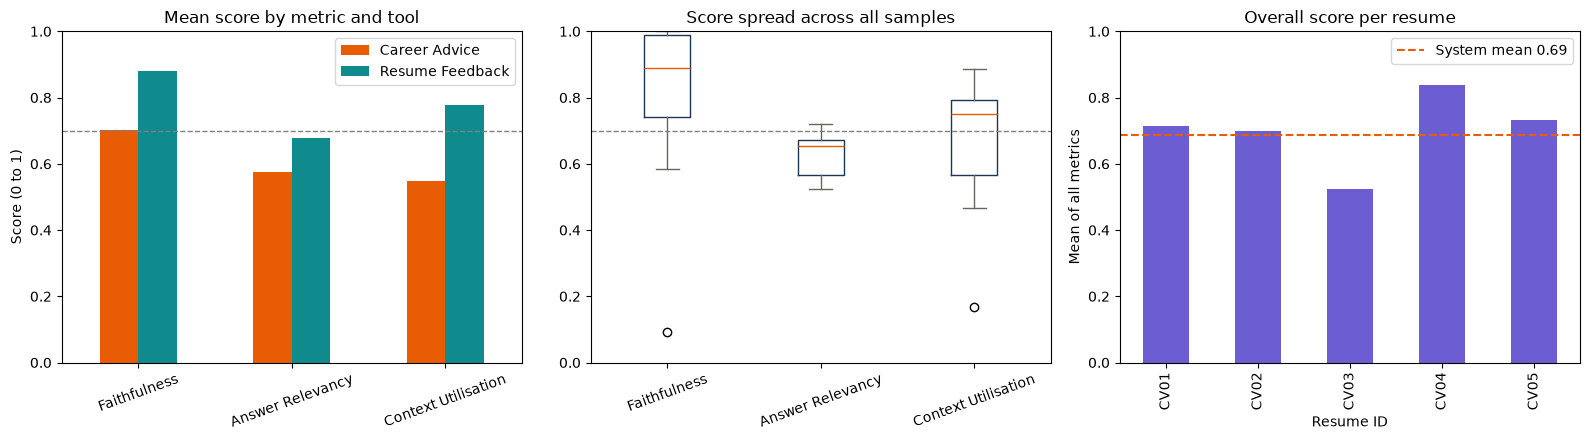

In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# 1. Mean score per metric, split by tool.
tool_means[METRIC_NAMES].T.plot(kind="bar", ax=axes[0], color=["#E85D04", "#0F8B8D"])
axes[0].set_title("Mean score by metric and tool")
axes[0].set_ylabel("Score (0 to 1)")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=20)
axes[0].legend(title="")
axes[0].axhline(0.7, color="grey", linestyle="--", linewidth=1)

# 2. Distribution of scores per metric. NaN rows are dropped so a failed sample
#    does not break the box plot.
box_data = all_scores[METRIC_NAMES].dropna(how="all")
box_data.plot(kind="box", ax=axes[1],
              color={"medians": "#E85D04", "boxes": "#1D3557",
                     "whiskers": "#6B6560", "caps": "#6B6560"})
axes[1].set_title("Score spread across all samples")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=20)
axes[1].axhline(0.7, color="grey", linestyle="--", linewidth=1)

# 3. Per-resume overall score.
per_resume = all_scores.groupby("Resume ID")[METRIC_NAMES].mean().mean(axis=1)
per_resume.plot(kind="bar", ax=axes[2], color="#6D5DD3")
axes[2].set_title("Overall score per resume")
axes[2].set_ylabel("Mean of all metrics")
axes[2].set_ylim(0, 1)
axes[2].axhline(overall_score, color="#E85D04", linestyle="--", linewidth=1.5,
                label=f"System mean {overall_score:.2f}")
axes[2].legend()

plt.tight_layout()
plt.show()


## 10. Export to Excel

Everything is written to a single workbook with one sheet per view:

| Sheet | Contents |
|---|---|
| `Overall Summary` | Headline numbers and the final system score |
| `Metric Guide` | What each metric means and how to read it |
| `Per Resume Scores` | Every sample with all metric scores |
| `Resume Feedback` | Scores for the Resume Feedback tool only |
| `Career Advice` | Scores for the Career Advice tool only |
| `Statistics` | Mean, median, spread and range per metric and scope |
| `Resumes Evaluated` | The resumes that were read, with word and skill counts |
| `Generated Answers` | The full text of every answer that was scored |
| `Retrieved Contexts` | The context chunks retrieved for each sample |

Score cells are colour scaled from red (low) to green (high) so weak areas are
visible at a glance.

In [16]:
metric_guide = pd.DataFrame([
    {"Metric": "Faithfulness",
     "What it measures": "Whether every claim in the answer is supported by the retrieved context.",
     "Why it matters": "A low score means the model is inventing advice that the knowledge base does not support.",
     "Range": "0 to 1, higher is better",
     "Target": "0.80 and above"},
    {"Metric": "Answer Relevancy",
     "What it measures": "Whether the answer directly addresses the request, without padding or drift.",
     "Why it matters": "A low score means the user asked for one thing and received something else.",
     "Range": "0 to 1, higher is better",
     "Target": "0.80 and above"},
    {"Metric": "Context Utilisation",
     "What it measures": "Whether the chunks the retriever ranked highest were the ones actually used.",
     "Why it matters": "A low score points at the retriever or the knowledge base, not the language model.",
     "Range": "0 to 1, higher is better",
     "Target": "0.70 and above"},
    {"Metric": "Rating bands",
     "What it measures": "Excellent 0.85+, Good 0.70 to 0.85, Acceptable 0.55 to 0.70, Weak 0.40 to 0.55, Poor below 0.40.",
     "Why it matters": "Gives a consistent plain-language reading of any score in this workbook.",
     "Range": "n/a",
     "Target": "n/a"},
])

answers_sheet = pd.DataFrame([{
    "Resume ID": s["resume_id"],
    "File": s["filename"],
    "Tool": s["tool"],
    "Generator": s["mode"],
    "Latency (s)": s["latency_s"],
    "Request": s["user_input"],
    "Generated answer": s["answer"],
} for s in samples])

contexts_sheet = pd.DataFrame([{
    "Resume ID": s["resume_id"],
    "Tool": s["tool"],
    "Retrieval query": s["retrieval_query"],
    "Chunk number": i + 1,
    "Source document": s["context_sources"][i],
    "Context text": ctx,
} for s in samples for i, ctx in enumerate(s["contexts"])])

resume_sheet = pd.DataFrame([{
    "Resume ID": r["resume_id"],
    "File": r["filename"],
    "Word count": r["word_count"],
    "Skills detected": len(r["detected_skills"]),
    "Detected skills": ", ".join(r["detected_skills"]),
} for r in resumes])

print("Sheets prepared:")
for name, frame in [("Overall Summary", overall_summary), ("Metric Guide", metric_guide),
                    ("Per Resume Scores", all_scores), ("Statistics", per_tool_summary),
                    ("Generated Answers", answers_sheet), ("Retrieved Contexts", contexts_sheet),
                    ("Resumes Evaluated", resume_sheet)]:
    print(f"  {name:<22} {len(frame)} rows")

Sheets prepared:
  Overall Summary        14 rows
  Metric Guide           4 rows
  Per Resume Scores      10 rows
  Statistics             9 rows
  Generated Answers      10 rows
  Retrieved Contexts     50 rows
  Resumes Evaluated      5 rows


### 10.1 Write the workbook


In [17]:
OUTPUT_PATH = RESULTS_DIR / f"Fit4Job_RAG_Evaluation_{time.strftime('%Y%m%d_%H%M')}.xlsx"

with pd.ExcelWriter(OUTPUT_PATH, engine="xlsxwriter") as writer:
    book = writer.book

    title_fmt = book.add_format({"bold": True, "font_size": 14, "font_color": "#1E1B18"})
    header_fmt = book.add_format({"bold": True, "bg_color": "#E85D04", "font_color": "white",
                                  "border": 1, "text_wrap": True, "valign": "vcenter"})
    text_fmt = book.add_format({"text_wrap": True, "valign": "top"})
    score_fmt = book.add_format({"num_format": "0.000", "border": 1})
    bold_fmt = book.add_format({"bold": True})

    def write_sheet(df, sheet_name, widths, score_cols=(), wrap_cols=()):
        # Guard against a widths list that has drifted out of step with the
        # dataframe (e.g. after a metric column is dropped).
        if len(widths) != len(df.columns):
            print(f"  note: '{sheet_name}' has {len(df.columns)} columns but "
                  f"{len(widths)} widths; padding/trimming to match.")
            widths = (list(widths) + [18] * len(df.columns))[:len(df.columns)]
        df.to_excel(writer, sheet_name=sheet_name, index=False, startrow=1)
        ws = writer.sheets[sheet_name]
        ws.write(0, 0, sheet_name, title_fmt)
        for col_idx, col_name in enumerate(df.columns):
            ws.write(1, col_idx, col_name, header_fmt)
        for col_idx, width in enumerate(widths):
            fmt = text_fmt if col_idx in wrap_cols else None
            ws.set_column(col_idx, col_idx, width, fmt)
        ws.freeze_panes(2, 0)
        ws.autofilter(1, 0, len(df) + 1, len(df.columns) - 1)
        # Red-to-green colour scale on score columns.
        for col_idx in score_cols:
            ws.conditional_format(2, col_idx, len(df) + 1, col_idx, {
                "type": "3_color_scale",
                "min_color": "#F8C9C4", "mid_color": "#FFF0B3", "max_color": "#C6E7D0",
                "min_type": "num", "min_value": 0,
                "mid_type": "num", "mid_value": 0.6,
                "max_type": "num", "max_value": 1,
            })
        return ws

    # --- Overall summary ---
    ws = write_sheet(overall_summary, "Overall Summary", [34, 40], wrap_cols=[1])
    last = len(overall_summary) + 1
    ws.write(last - 1, 0, "OVERALL SCORE", bold_fmt)
    ws.write(last, 0, "Rating", bold_fmt)

    # --- Metric guide ---
    write_sheet(metric_guide, "Metric Guide", [22, 56, 56, 24, 18], wrap_cols=[1, 2])

    # --- Per resume scores (all samples) ---
    score_idx = [all_scores.columns.get_loc(m) for m in METRIC_NAMES]
    write_sheet(all_scores.round(4), "Per Resume Scores",
                [12, 26, 18] + [18] * len(METRIC_NAMES) + [12, 12, 14],
                score_cols=score_idx)

    # --- One sheet per tool ---
    for frame, sheet in [(feedback_scores, "Resume Feedback"), (advice_scores, "Career Advice")]:
        if frame.empty:
            continue
        idx = [frame.columns.get_loc(m) for m in METRIC_NAMES]
        write_sheet(frame.round(4), sheet,
                    [12, 26, 18] + [18] * len(METRIC_NAMES) + [12, 12, 14],
                    score_cols=idx)

    # --- Statistics ---
    stats = per_tool_summary.round(4)
    write_sheet(stats, "Statistics", [18, 22, 12, 12, 12, 12, 12, 10],
                score_cols=[2, 3, 5, 6])

    # --- Resumes evaluated ---
    write_sheet(resume_sheet, "Resumes Evaluated", [12, 26, 12, 16, 70], wrap_cols=[4])

    # --- Generated answers ---
    write_sheet(answers_sheet, "Generated Answers", [12, 24, 18, 12, 12, 44, 100],
                wrap_cols=[5, 6])

    # --- Retrieved contexts ---
    write_sheet(contexts_sheet, "Retrieved Contexts", [12, 18, 34, 12, 24, 100],
                wrap_cols=[2, 5])

print(f"Saved: {OUTPUT_PATH}")
print(f"Size : {OUTPUT_PATH.stat().st_size / 1024:.1f} KB")
print("\nSheets written:")
print("  Overall Summary, Metric Guide, Per Resume Scores, Resume Feedback,")
print("  Career Advice, Statistics, Resumes Evaluated, Generated Answers,")
print("  Retrieved Contexts")

Saved: D:\1. UNI\Final Reserch Project\fit4job\evaluation_results\Fit4Job_RAG_Evaluation_20260901_1231.xlsx
Size : 25.3 KB

Sheets written:
  Overall Summary, Metric Guide, Per Resume Scores, Resume Feedback,
  Career Advice, Statistics, Resumes Evaluated, Generated Answers,
  Retrieved Contexts


## 11. Conclusion

The cell below prints a short written verdict you can paste directly into the
dissertation's evaluation chapter, including the strongest and weakest metric
and what each result implies about the system.

In [18]:
best_metric = overall_by_metric.idxmax()
worst_metric = overall_by_metric.idxmin()

diagnosis = {
    "Faithfulness": "the generated advice sometimes goes beyond what the knowledge base "
                    "supports; expanding the knowledge base or tightening the prompt would help",
    "Answer Relevancy": "answers sometimes drift from the specific request; making the prompt "
                        "instruction more explicit would help",
    "Context Utilisation": "the retriever is surfacing chunks the model does not end up using; "
                           "tuning top_k or improving chunking would help",
}


def tool_mean(df: pd.DataFrame) -> float:
    """Mean across all metrics for one tool, or NaN if it has no scores."""
    cols = [m for m in METRIC_NAMES if m in df.columns]
    return float(df[cols].mean().mean()) if cols and not df.empty else float("nan")


print("EVALUATION CONCLUSION")
print("=" * 62)
print(f"The Fit4Job RAG system was evaluated on {all_scores['Resume ID'].nunique()} resumes")
print(f"across its two generative career tools, producing {len(all_scores)} scored samples")
print(f"judged by {JUDGE_MODEL} through the RAGAS framework.")
print()
print(f"The system achieved an overall score of {overall_score:.3f} ({band(overall_score)}).")
print()
print(f"Strongest metric: {best_metric} at {overall_by_metric[best_metric]:.3f}.")
print(f"Weakest metric  : {worst_metric} at {overall_by_metric[worst_metric]:.3f}.")
print(f"This suggests {diagnosis.get(worst_metric, 'reviewing that stage of the pipeline')}.")
print()

fb_mean, ca_mean = tool_mean(feedback_scores), tool_mean(advice_scores)
if pd.notna(fb_mean) and pd.notna(ca_mean):
    stronger = "Resume Feedback" if fb_mean >= ca_mean else "Career Advice"
    print(f"By tool, Resume Feedback scored {fb_mean:.3f} and Career Advice scored {ca_mean:.3f},")
    print(f"making {stronger} the stronger of the two by {abs(fb_mean - ca_mean):.3f}.")
    print()

print(f"Full results: {OUTPUT_PATH.name}")
print("=" * 62)


EVALUATION CONCLUSION
The Fit4Job RAG system was evaluated on 5 resumes
across its two generative career tools, producing 10 scored samples
judged by openai/gpt-oss-20b through the RAGAS framework.

The system achieved an overall score of 0.688 (Acceptable).

Strongest metric: Faithfulness at 0.791.
Weakest metric  : Answer Relevancy at 0.626.
This suggests answers sometimes drift from the specific request; making the prompt instruction more explicit would help.

By tool, Resume Feedback scored 0.779 and Career Advice scored 0.608,
making Resume Feedback the stronger of the two by 0.171.

Full results: Fit4Job_RAG_Evaluation_20260901_1231.xlsx
